In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

mom126 = (
    close
    .pct_change(126)
    .shift(1)
)

In [3]:
def backtest_rebalance(rebalance_days):

    rebalance_dates = close.index[
        126::rebalance_days
    ]

    portfolio_returns = []

    for i in range(len(rebalance_dates)-1):

        start = rebalance_dates[i]
        end = rebalance_dates[i+1]

        scores = mom126.loc[start]

        selected = (
            scores
            .dropna()
            .nlargest(20)
            .index
        )

        period_return = (
            close.loc[end, selected]
            /
            close.loc[start, selected]
            - 1
        ).mean()

        portfolio_returns.append(
            period_return
        )

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=rebalance_dates[:-1]
    )

    equity = (
        1 + portfolio_returns
    ).cumprod()

    cagr = (
        equity.iloc[-1]
        **
        (
            252 / len(close)
        )
        - 1
    )

    sharpe = (
        portfolio_returns.mean()
        /
        portfolio_returns.std()
    ) * np.sqrt(
        252/rebalance_days
    )

    max_dd = (
        equity
        /
        equity.cummax()
        - 1
    ).min()

    return {
        "Total Return":
            equity.iloc[-1]-1,
        "CAGR":
            cagr,
        "Sharpe":
            sharpe,
        "MaxDD":
            max_dd,
        "Equity":
            equity
    }

In [4]:
freqs = [
    21,
    42,
    63,
    126
]

results = {}

for f in freqs:

    results[f] = backtest_rebalance(f)

In [5]:
summary = pd.DataFrame({

    "Total Return":[
        results[f]["Total Return"]
        for f in freqs
    ],

    "CAGR":[
        results[f]["CAGR"]
        for f in freqs
    ],

    "Sharpe":[
        results[f]["Sharpe"]
        for f in freqs
    ],

    "MaxDD":[
        results[f]["MaxDD"]
        for f in freqs
    ]

},
index=[
    "21D",
    "42D",
    "63D",
    "126D"
])

summary

,Total Return,CAGR,Sharpe,MaxDD
21D,36.859638,0.400970,1.402413,-0.340065
42D,38.916231,0.407863,1.388295,-0.279136
63D,29.238712,0.372056,1.174427,-0.258202
126D,26.508164,0.360061,1.138803,-0.217442


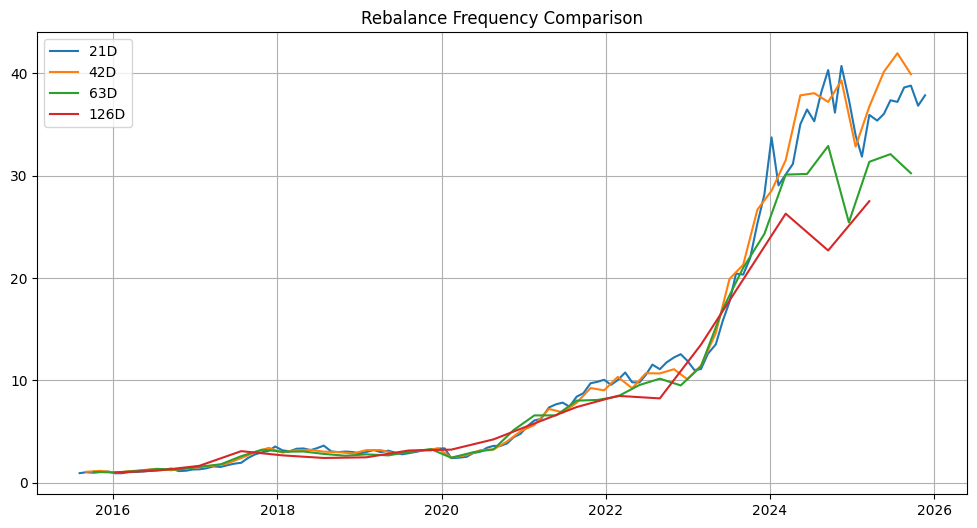

In [9]:
plt.figure(figsize=(12,6))

for f in freqs:

    plt.plot(
        results[f]["Equity"],
        label=f"{f}D"
    )

plt.title(
    "Rebalance Frequency Comparison"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/plots/04_rebalance_equity_curves.png",
    bbox_inches="tight"
)

plt.show()

In [ ]:
summary.to_csv(
    "../results/tables/04_rebalance_summary.csv"
)



<Figure size 640x480 with 0 Axes>

## Rebalance Frequency Analysis

Results:

| Frequency | CAGR | Sharpe | Max Drawdown |
|------------|------------|------------|------------|
| 21 Days | 40.10% | 1.40 | -34.0% |
| 42 Days | 40.79% | 1.39 | -27.9% |
| 63 Days | 37.21% | 1.17 | -25.8% |
| 126 Days | 36.01% | 1.14 | -21.7% |

Findings:

- More frequent rebalancing improved momentum capture.
- 42-day rebalancing achieved the highest CAGR.
- 21-day rebalancing achieved the highest Sharpe ratio but experienced larger drawdowns.
- 42-day rebalancing provided the best balance between return and risk.
- Momentum alpha decays when portfolios are held for excessively long periods.